In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [3]:
import os

print(os.getcwd())

d:\smart_retail_ai\notebooks


In [4]:
import os

print(os.listdir())

['01_product_classifier_training.ipynb', 'download_dataset.py', 'fashion_mnist_training.ipynb']


In [5]:
import pandas as pd

train = pd.read_csv(r"D:\smart_retail_ai\datasets\fashion-mnist_train.csv")
test = pd.read_csv(r"D:\smart_retail_ai\datasets\fashion-mnist_test.csv")

print(train.shape)
print(test.shape)

(60000, 785)
(10000, 785)


In [6]:
X_train = train.drop("label", axis=1).values
y_train = train["label"].values

X_test = test.drop("label", axis=1).values
y_test = test["label"].values

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [9]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.7369 - loss: 0.7298 - val_accuracy: 0.8627 - val_loss: 0.3755
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8650 - loss: 0.3715 - val_accuracy: 0.8892 - val_loss: 0.3095
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 43ms/step - accuracy: 0.8838 - loss: 0.3205 - val_accuracy: 0.8953 - val_loss: 0.2880
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.8977 - loss: 0.2815 - val_accuracy: 0.9060 - val_loss: 0.2630
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.9057 - loss: 0.2543 - val_accuracy: 0.9063 - val_loss: 0.2579
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 42ms/step - accuracy: 0.9129 - loss: 0.2273 - val_accuracy: 0.9119 - val_loss: 0.2500
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.9190 - loss: 0.2117 - val_accuracy: 0.9076 - val_loss: 0.2590
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9258 -

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9116 - loss: 0.2438
Test Accuracy: 0.9156000018119812


In [14]:
model.save(r"D:\smart_retail_ai\backend\app\models\product_classifier.keras")

In [15]:
prediction = model.predict(X_test[:1])

predicted_class = prediction.argmax()

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Predicted: T-shirt
Actual: T-shirt


In [16]:
correct = 0

for i in range(20):
    pred = np.argmax(model.predict(X_test[i:i+1], verbose=0))
    print(
        f"Actual: {class_names[y_test[i]]}, "
        f"Predicted: {class_names[pred]}"
    )
    if pred == y_test[i]:
        correct += 1

print(f"Correct: {correct}/20")

Actual: T-shirt, Predicted: T-shirt
Actual: Trouser, Predicted: Trouser
Actual: Pullover, Predicted: Pullover
Actual: Pullover, Predicted: Pullover
Actual: Dress, Predicted: Dress
Actual: Pullover, Predicted: Shirt
Actual: Bag, Predicted: Bag
Actual: Shirt, Predicted: Shirt
Actual: Sandal, Predicted: Sandal
Actual: T-shirt, Predicted: T-shirt
Actual: Dress, Predicted: Dress
Actual: Coat, Predicted: Pullover
Actual: Coat, Predicted: Coat
Actual: Shirt, Predicted: Shirt
Actual: Bag, Predicted: Bag
Actual: Sandal, Predicted: Sandal
Actual: Shirt, Predicted: Shirt
Actual: Dress, Predicted: Dress
Actual: Shirt, Predicted: Shirt
Actual: Coat, Predicted: Coat
Correct: 18/20


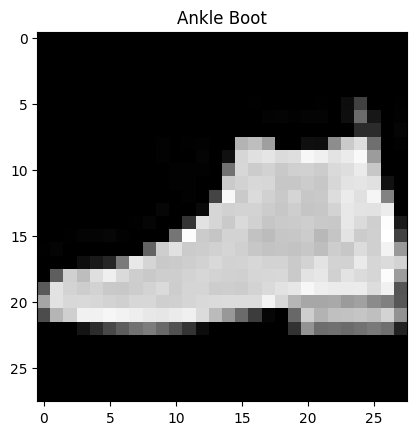

Predicted: Ankle Boot
Actual: Ankle Boot


In [17]:
idx = 100

plt.imshow(X_test[idx].reshape(28,28), cmap="gray")
plt.title(class_names[y_test[idx]])
plt.show()

pred = np.argmax(model.predict(X_test[idx:idx+1], verbose=0))
print("Predicted:", class_names[pred])
print("Actual:", class_names[y_test[idx]])